Imports:

In [90]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import cv2 as cv
from time import time
from os import path
import re


import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt



Ficheiro auxiliar (Moodle):

In [91]:
# Tabelas da norma ITU T.81 - JPEG standa

# tabela K1 - Luminance quantize Matrix  
Q = np.zeros((8, 8))
Q[0] = [ 16,  11,  10,  16,  24,  40,  51,  61]
Q[1] = [ 12,  12,  14,  19,  26,  58,  60,  55]
Q[2] = [ 14,  13,  16,  24,  40,  57,  69,  56]
Q[3] = [ 14,  17,  22,  29,  51,  87,  80,  62]
Q[4] = [ 18,  22,  37,  56,  68, 109, 103,  77]
Q[5] = [ 24,  35,  55,  64,  81, 104, 113,  92]
Q[6] = [ 49,  64,  78,  87, 103, 121, 120, 101]
Q[7] = [ 72,  92,  95,  98, 112, 100, 103,  99]

# Tabela K3 
# Table for luminance DC coefficient differences
K3 = dict()
K3[0] = "00"
K3[1] = "010"
K3[2] = "011"
K3[3] = "100"
K3[4] = "101"
K3[5] = "110"
K3[6] = "1110"
K3[7] = "11110"
K3[8] = "111110"
K3[9] = "1111110"
K3[10] = "11111110"
K3[11] = "111111110"

# Tabela K5 
# Table for luminance AC coefficients
K5 = dict()
K5[(0, 0)] = "1010"
K5[(0, 1)] = "00"
K5[(0, 2)] = "01"
K5[(0, 3)] = "100"
K5[(0, 4)] = "1011"
K5[(0, 5)] = "11010"
K5[(0, 6)] = "1111000"
K5[(0, 7)] = "11111000"
K5[(0, 8)] = "1111110110"
K5[(0, 9)] = "1111111110000010"
K5[(0,10)] = "1111111110000011"

K5[(1, 1)] = "1100"
K5[(1, 2)] = "11011"
K5[(1, 3)] = "1111001"
K5[(1, 4)] = "111110110"
K5[(1, 5)] = "11111110110"
K5[(1, 6)] = "1111111110000100"
K5[(1, 7)] = "1111111110000101"
K5[(1, 8)] = "1111111110000110"
K5[(1, 9)] = "1111111110000111"
K5[(1,10)] = "1111111110001000"

K5[(2, 1)] = "11100"
K5[(2, 2)] = "11111001"
K5[(2, 3)] = "1111110111"
K5[(2, 4)] = "111111110100"
K5[(2, 5)] = "1111111110001001"
K5[(2, 6)] = "1111111110001010"
K5[(2, 7)] = "1111111110001011"
K5[(2, 8)] = "1111111110001100"
K5[(2, 9)] = "1111111110001101"
K5[(2,10)] = "1111111110001110"

K5[(3, 1)] = "111010"
K5[(3, 2)] = "111110111"
K5[(3, 3)] = "111111110101"
K5[(3, 4)] = "1111111110001111"
K5[(3, 5)] = "1111111110010000"
K5[(3, 6)] = "1111111110010001"
K5[(3, 7)] = "1111111110010010"
K5[(3, 8)] = "1111111110010011"
K5[(3, 9)] = "1111111110010100"
K5[(3,10)] = "1111111110010101"

K5[(4, 1)] = "111011"
K5[(4, 2)] = "1111111000"
K5[(4, 3)] = "1111111110010110"
K5[(4, 4)] = "1111111110010111"
K5[(4, 5)] = "1111111110011000"
K5[(4, 6)] = "1111111110011001"
K5[(4, 7)] = "1111111110011010"
K5[(4, 8)] = "1111111110011011"
K5[(4, 9)] = "1111111110011100"
K5[(4,10)] = "1111111110011101"

K5[(5, 1)] = "1111010"
K5[(5, 2)] = "11111110111"
K5[(5, 3)] = "1111111110011110"
K5[(5, 4)] = "1111111110011111"
K5[(5, 5)] = "1111111110100000"
K5[(5, 6)] = "1111111110100001"
K5[(5, 7)] = "1111111110100010"
K5[(5, 8)] = "1111111110100011"
K5[(5, 9)] = "1111111110100100"
K5[(5,10)] = "1111111110100101"

K5[(6, 1)] = "1111011"
K5[(6, 2)] = "111111110110"
K5[(6, 3)] = "1111111110100110"
K5[(6, 4)] = "1111111110100111"
K5[(6, 5)] = "1111111110101000"
K5[(6, 6)] = "1111111110101001"
K5[(6, 7)] = "1111111110101010"
K5[(6, 8)] = "1111111110101011"
K5[(6, 9)] = "1111111110101100"
K5[(6,10)] = "1111111110101101"

K5[(7, 1)] = "11111010"
K5[(7, 2)] = "111111110111"
K5[(7, 3)] = "1111111110101110"
K5[(7, 4)] = "1111111110101111"
K5[(7, 5)] = "1111111110110000"
K5[(7, 6)] = "1111111110110001"
K5[(7, 7)] = "1111111110110010"
K5[(7, 8)] = "1111111110110011"
K5[(7, 9)] = "1111111110110100"
K5[(7,10)] = "1111111110110101"

K5[(8, 1)] = "111111000"
K5[(8, 2)] = "111111111000000"
K5[(8, 3)] = "1111111110110110"
K5[(8, 4)] = "1111111110110111"
K5[(8, 5)] = "1111111110111000"
K5[(8, 6)] = "1111111110111001"
K5[(8, 7)] = "1111111110111010"
K5[(8, 8)] = "1111111110111011"
K5[(8, 9)] = "1111111110111100"
K5[(8,10)] = "1111111110111101"

K5[(9, 1)] = "111111001"
K5[(9, 2)] = "1111111110111110"
K5[(9, 3)] = "1111111110111111"
K5[(9, 4)] = "1111111111000000"
K5[(9, 5)] = "1111111111000001"
K5[(9, 6)] = "1111111111000010"
K5[(9, 7)] = "1111111111000011"
K5[(9, 8)] = "1111111111000100"
K5[(9, 9)] = "1111111111000101"
K5[(9,10)] = "1111111111000110"

K5[(10, 1)] = "111111010"
K5[(10, 2)] = "1111111111000111"
K5[(10, 3)] = "1111111111001000"
K5[(10, 4)] = "1111111111001001"
K5[(10, 5)] = "1111111111001010"
K5[(10, 6)] = "1111111111001011"
K5[(10, 7)] = "1111111111001100"
K5[(10, 8)] = "1111111111001101"
K5[(10, 9)] = "1111111111001110"
K5[(10,10)] = "1111111111001111"

K5[(11, 1)] = "1111111001"
K5[(11, 2)] = "1111111111010000"
K5[(11, 3)] = "1111111111010001"
K5[(11, 4)] = "1111111111010010"
K5[(11, 5)] = "1111111111010011"
K5[(11, 6)] = "1111111111010100"
K5[(11, 7)] = "1111111111010101"
K5[(11, 8)] = "1111111111010110"
K5[(11, 9)] = "1111111111010111"
K5[(11,10)] = "1111111111011000"

K5[(12, 1)] = "1111111010"
K5[(12, 2)] = "1111111111011001"
K5[(12, 3)] = "1111111111011010"
K5[(12, 4)] = "1111111111011011"
K5[(12, 5)] = "1111111111011100"
K5[(12, 6)] = "1111111111011101"
K5[(12, 7)] = "1111111111011110"
K5[(12, 8)] = "1111111111011111"
K5[(12, 9)] = "1111111111100000"
K5[(12,10)] = "1111111111100001"

K5[(13, 1)] = "11111111000"
K5[(13, 2)] = "1111111111100010"
K5[(13, 3)] = "1111111111100011"
K5[(13, 4)] = "1111111111100100"
K5[(13, 5)] = "1111111111100101"
K5[(13, 6)] = "1111111111100110"
K5[(13, 7)] = "1111111111100111"
K5[(13, 8)] = "1111111111101000"
K5[(13, 9)] = "1111111111101001"
K5[(13,10)] = "1111111111101010"

K5[(14, 1)] = "1111111111101011"
K5[(14, 2)] = "1111111111101100"
K5[(14, 3)] = "1111111111101101"
K5[(14, 4)] = "1111111111101110"
K5[(14, 5)] = "1111111111101111"
K5[(14, 6)] = "1111111111110000"
K5[(14, 7)] = "1111111111110001"
K5[(14, 8)] = "1111111111110010"
K5[(14, 9)] = "1111111111110011"
K5[(14,10)] = "1111111111110100"

K5[(15, 0)] = "11111111001"
K5[(15, 1)] = "1111111111110101"
K5[(15, 2)] = "1111111111110110"
K5[(15, 3)] = "1111111111110111"
K5[(15, 4)] = "1111111111111000"
K5[(15, 5)] = "1111111111111001"
K5[(15, 6)] = "1111111111111010"
K5[(15, 7)] = "1111111111111011"
K5[(15, 8)] = "1111111111111100"
K5[(15, 9)] = "1111111111111101"
K5[(15,10)] = "1111111111111110"

# ordem zig-zag 
zigzag = np.zeros((8, 8))
zigzag[0] = [ 0,  1,  5,  6, 14, 15, 27, 28]
zigzag[1] = [ 2,  4,  7, 13, 16, 26, 29, 42]
zigzag[2] = [ 3,  8, 12, 17, 25, 30, 41, 43]
zigzag[3] = [ 9, 11, 18, 24, 31, 40, 44, 53]
zigzag[4] = [10, 19, 23, 32, 39, 45, 52, 54]
zigzag[5] = [20, 22, 33, 38, 46, 51, 55, 60]
zigzag[6] = [21, 34, 37, 47, 50, 56, 59, 61]
zigzag[7] = [35, 36, 48, 49, 57, 58, 62, 63]
zigzag=zigzag.astype('int16')
ind_zz = np.argsort(zigzag.reshape((64),order='F').astype('int16'))

##########################################################################
#
#   Função para calcular o valor a multiplicar  a tabela K1 a
#   partir do fator de qualidade
#
##########################################################################

def quality_factor(q):
    if(q <= 50):
        factor = 50.0 / q
    else:
        factor = 2.0 - (q * 2.0)/100.0
    return factor 



# 1.

# a) Codificador e descodificador

Antes de aplicar o codificador e o descodificador, é necessário ler a imagem em 'grayscale' (tons de cinzento) e garantir que as suas dimensões sejam um múltiplo de 8, caso contrário, o corte em blocos de 8 por 8 irá falhar nas bordas da imagem.

In [92]:
im = cv.imread('./lena.tif', cv.IMREAD_GRAYSCALE)

if im is None:
    print("Erro: Imagem não encontrada.")
else:
    linhas, colunas = im.shape
    
    # Garante que as novas dimensões sejam pelo menos 8x8
    h = (linhas // 8) * 8
    w = (colunas // 8) * 8
    
    # Verifica se os valores são válidos antes de redimensionar
    if h > 0 and w > 0:
        # A ordem aqui é (largura, altura)
        imagem = cv.resize(im, (w, h))
    else:
        print("Erro: As dimensões calculadas são inválidas.")

## O que é a DCT?

A DCT (discrete cosine transform) ou transformada de cosseno, à semelhança da transformada de Fourier, é um método que nos permite transformar sinais no domínio do tempo/espaço para o domínio da frequência; é uma das componentes mais importantes para compressão de imagem e áudio.

## Como se distingue da FFT?

No caso da FFT (fast Fourier transform), cada coeficiente é representado por um exponencial complexo (e^(jwt)), ou seja, uma soma entre um seno e um cosseno. No caso da DCT, cada coeficiente é dado apenas por um cosseno (cos(wt)), não sendo necessária a utilização de expoentes complexos (já que cada coeficiente acaba sempre por ser um número real). 

A DCT tem menos informação para aramzenar comparativamente à FFT (porque discarta o seno), assim como uma implementação mais simples, porém a DCT assume que o sinal se repete fora dos limites de forma simétrica; e como tal, discarta o seno já que este representa uma função ímpar.

## Porque é que é útil na compressão?

A DCT é extremamente útil na compressão de imagem já que esta concentra a maior parte da energia do sinal nos primeiros coeficientes, descartando os com pequena energia sem grande perda visual.

## Codificador:

Para realizar a transformada de cosseno discreta, será necessário utilizar o método 'cv2.dct()' que recebe valores do tipo 'float32', e como tal, será necessário converter os pixeis (já que estes são representados por um inteiro de 8 bits ('uint8')) antes de realizar a DCT.

Os pixeis da imagem serão percorridos, "recortando" um bloco de 8x8 e convertendo-o para 'float32' a cada iteração.

Após o "recorte", é feita efetivamente a transformada de cosseno desse mesmo bloco recortado, guardando-o na lista 'dct', na mesma posição em que foi recortado na imagem.

In [93]:
def codificador(imagem):

    linhas, colunas = imagem.shape
    dct = np.zeros((linhas, colunas))
    dct = dct* 1.0 

    for a in range(0, linhas, 8):
        for b in range(0, colunas, 8):
            bloco_oito = imagem[a:a+8, b:b+8]
            bloco_oito = bloco_oito * 1.0
            dct[a:a+8, b:b+8] = cv.dct(bloco_oito)
            
    return dct

Implementação prática:

In [94]:
lena_codificada = codificador(imagem)

## Descodificador

O descodificador faz exatamente o contrário do codificador, pega nos coeficientes codificados pela DCT, e recria o sinal partindo dos mesmos.

Para realizar a descodificação, será utilizado o método 'cv2.idct', que representa uma transformada de cosseno 'inversa', recebendo a lista de coeficientes (como a lista retornada pelo codificador).

In [95]:
def descodificador(codificada):

    linhas, colunas = codificada.shape
    idct = np.zeros((linhas, colunas))
    idct = idct *1.0

    for a in range(0, linhas, 8):
        for b in range(0, colunas, 8):
            bloco_oito = codificada[a:a+8, b:b+8]
            bloco_oito = bloco_oito * 1.0
            idct[a:a+8, b:b+8] = cv.idct(bloco_oito)
            
    return idct

Implementação prática:

In [96]:
lena_descodificada = descodificador(lena_codificada)

Visualização:

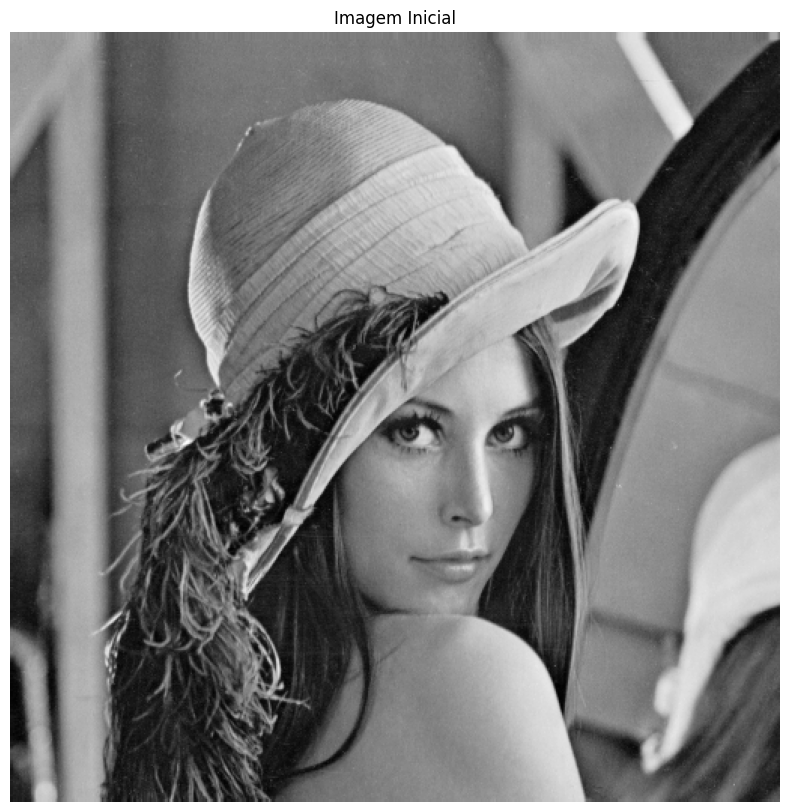

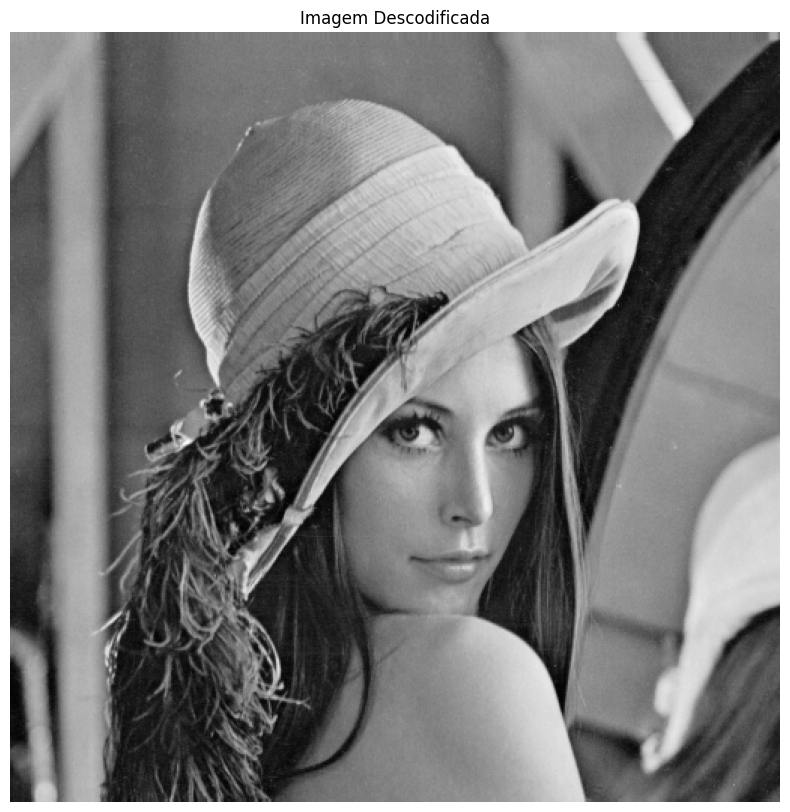

In [97]:
plt.figure(figsize=(10, 10))
plt.axis('off')
plt.title('Imagem Inicial')
plt.imshow(imagem, cmap= 'gray')

plt.figure(figsize=(10, 10))
plt.axis('off')
plt.title('Imagem Descodificada')
plt.imshow(lena_descodificada, cmap='gray')

As duas imagens são iguais, mostrando que a codificação e descodificação foram bem feitas.

## b) Quantificação

## A importância deste passo:

Durante este passo do JPEG, haverá realmente alguma perda de informação.
Vamos pegar no bloco de frequências proveniente da transformada de cosseno (DCT, realizada na alínea anterior) e vamos dividi-lo por uma "matriz de penalização" (a matriz 'Q'), multiplicando-a por um fator de qualidade; depois, o resultado será arredondado para o número inteiro mais próximo.

Como o olho humano tem mais dificuldade a percecionar detalhes mais minuciosos, a quantificação sacrifica esses mesmos detalhes (cantos inferiores da tabela 'Q') com o propósito de diminuir o tamanho do ficheiro.

In [98]:
def quantificador(dct, Q, qualidade):
    linhas, colunas = dct.shape
    quantificada = np.zeros((linhas, colunas))
    fator = quality_factor(qualidade)
    matriz_q = Q * fator
    
    for i in range(0, linhas, 8):
        for j in range(0, colunas, 8):
            bloco =dct[i:i+8, j:j+8]
            quantificada[i:i+8, j:j+8] = np.round(bloco / matriz_q)
            quantificada = quantificada * 1
            
    return quantificada

In [99]:
def desquantificador(img_quant, Q, q):
    linhas, colunas = img_quant.shape
    
    desquantificada = np.zeros((linhas, colunas))
    desquantificada = desquantificada * 1.0

    fator = quality_factor(q)
    matriz_q = Q * fator
    
    for i in range(0, linhas, 8):
        for j in range(0, colunas, 8):
            bloco_q = img_quant[i:i+8, j:j+8]
            
            desquantificada[i:i+8, j:j+8] = bloco_q * matriz_q
            
    return desquantificada

Implementação prática:

In [100]:
lena_quantificada = quantificador(lena_codificada, Q, 50)

Cálculo do SNR:

Será calculada a relação sinal-ruído (SNR) para observar concretamente a perda de informação em relação à imagem inicial.

In [101]:
SNR = 10 * np.log10(np.sum(lena_codificada**2) / np.sum((lena_codificada - lena_quantificada)**2))

Visualização:

SNR: 0.5629429677771773


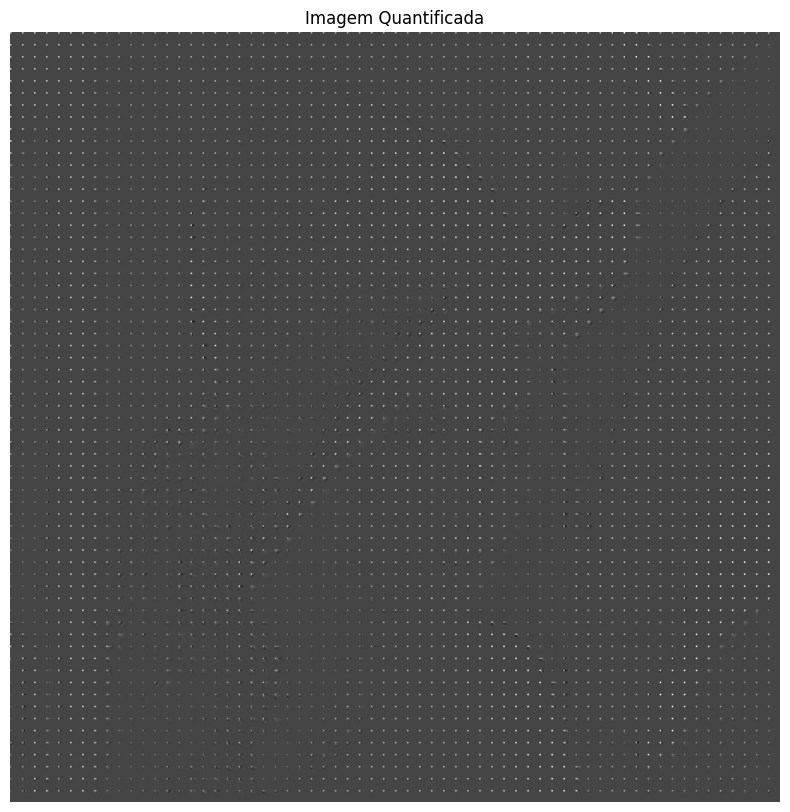

In [102]:
plt.figure(figsize=(10, 10))
plt.axis('off')
plt.title('Imagem Quantificada')
plt.imshow(lena_quantificada, cmap='gray')

print("SNR:", SNR)

## c) Coeficientes DC

## O que representam os coeficientes DC?

O primeiro coeficiente de cada bloco é chamado de 'DC' e representa o brilho médio desse mesmo bloco. 
Para este passo não será guardado propriamente o valor DC do bloco, mas sim a diferença entre a DC do bloco atual e a DC do bloco anterior, já que raramente existe um grande contraste de brilho entre dois blocos de 8 por 8 adjacentes.
É mais útil armazenar a diferença entre dois blocos já que armazenar o coeficiente DC de cada bloco ocupará mais espaço do que apenas a diferença entre dois, já que (como foi mencionado anteriormente) não haverá grande contraste entre eles.

In [103]:
def dc(img_quantificada):
    linhas, colunas = img_quantificada.shape
    dcs = []
    for i in range(0, linhas, 8):
        for j in range(0, colunas, 8):
            dcs.append(img_quantificada[i, j])
            
    diferença = [dcs[0]]

    for k in range(1, len(dcs)):
        diferença.append(dcs[k] - dcs[k-1]) # diferença entre a DC do bloco atual e a DC do bloco anterior
    return diferença

## Descodificador DC:

Para criar a função do descodificador das diferenças DC, é necessário realizar o processo inverso, em que iremos somar (ao contrário da função anterior) o bloco de DCs descodificadas anterior ao bloco de diferenças atual; sendo o bloco de diferenças descodificadas inicializado com o primeiro valor da lista de diferenças (já que o bloco anterior a esse é 0).
Finalmente, será retornada a lista com os coeficientes DC descodificados.

In [104]:
def descodificador_dc(diferenças):
    dcs = [diferenças[0]]

    for i in range(1, len(diferenças)):
        
        dcs.append(diferenças[i] + dcs[-1])
        
    return dcs

Implementação prática:

In [105]:
diferenças_dc = dc(lena_quantificada)
dc_descodificadas = descodificador_dc(diferenças_dc)

Print das diferenças:

In [106]:
for i in range(1, len(diferenças_dc)):
    print(f"Bloco {i}, diferença DC: {diferenças_dc[i]}")

Bloco 1, diferença DC: -1.0
Bloco 2, diferença DC: -1.0
Bloco 3, diferença DC: -1.0
Bloco 4, diferença DC: 2.0
Bloco 5, diferença DC: 6.0
Bloco 6, diferença DC: -1.0
Bloco 7, diferença DC: -18.0
Bloco 8, diferença DC: -19.0
Bloco 9, diferença DC: 5.0
Bloco 10, diferença DC: 1.0
Bloco 11, diferença DC: 0.0
Bloco 12, diferença DC: 0.0
Bloco 13, diferença DC: 4.0
Bloco 14, diferença DC: 4.0
Bloco 15, diferença DC: 2.0
Bloco 16, diferença DC: 2.0
Bloco 17, diferença DC: 1.0
Bloco 18, diferença DC: -1.0
Bloco 19, diferença DC: 1.0
Bloco 20, diferença DC: 1.0
Bloco 21, diferença DC: 0.0
Bloco 22, diferença DC: -1.0
Bloco 23, diferença DC: 0.0
Bloco 24, diferença DC: 1.0
Bloco 25, diferença DC: 0.0
Bloco 26, diferença DC: 0.0
Bloco 27, diferença DC: -2.0
Bloco 28, diferença DC: 1.0
Bloco 29, diferença DC: -1.0
Bloco 30, diferença DC: 2.0
Bloco 31, diferença DC: -1.0
Bloco 32, diferença DC: 0.0
Bloco 33, diferença DC: -1.0
Bloco 34, diferença DC: 0.0
Bloco 35, diferença DC: -1.0
Bloco 36, dife

Print das DC descodificadas:

In [107]:
for i in range(1, len(dc_descodificadas)):
    print(f"Bloco {i}, DC descodificada: {dc_descodificadas[i]}")

Bloco 1, DC descodificada: 79.0
Bloco 2, DC descodificada: 78.0
Bloco 3, DC descodificada: 77.0
Bloco 4, DC descodificada: 79.0
Bloco 5, DC descodificada: 85.0
Bloco 6, DC descodificada: 84.0
Bloco 7, DC descodificada: 66.0
Bloco 8, DC descodificada: 47.0
Bloco 9, DC descodificada: 52.0
Bloco 10, DC descodificada: 53.0
Bloco 11, DC descodificada: 53.0
Bloco 12, DC descodificada: 53.0
Bloco 13, DC descodificada: 57.0
Bloco 14, DC descodificada: 61.0
Bloco 15, DC descodificada: 63.0
Bloco 16, DC descodificada: 65.0
Bloco 17, DC descodificada: 66.0
Bloco 18, DC descodificada: 65.0
Bloco 19, DC descodificada: 66.0
Bloco 20, DC descodificada: 67.0
Bloco 21, DC descodificada: 67.0
Bloco 22, DC descodificada: 66.0
Bloco 23, DC descodificada: 66.0
Bloco 24, DC descodificada: 67.0
Bloco 25, DC descodificada: 67.0
Bloco 26, DC descodificada: 67.0
Bloco 27, DC descodificada: 65.0
Bloco 28, DC descodificada: 66.0
Bloco 29, DC descodificada: 65.0
Bloco 30, DC descodificada: 67.0
Bloco 31, DC descod

As diferenças obtidas pelo codificador DC são iguais às diferenças entre os blocos de 8 por 8 obtidas pelo descodificador.

## d) Coeficientes AC

## O que representam os coeficientes AC?

Os restantes 63 coeficientes do bloco de 8 por 8 chamam-se de "coeficientes AC", estes representam o detalhe da imagem.
Depois de quantificar a imagem, foi perdida uma grande parte do detalhe da imagem, já que as frequências altas foram reduzidas a zero.
Se a matriz fosse lida linha a linha, encontrariamos zeros espalhados.

## Leitura em zig-zag:

Para resolver o problema dos 'zeros espalhados', irá ser realizada uma leitura em zig-zag, utilizando o vetor 'vetor_zz'.
Ao ler em zig-zag garantimos que os zeros sejam lidos no final do vetor; e como os zeros são lidos todos de uma vez no final, não será necessário ler cada um individualmente. O algoritmo RLE marca o final do bloco, sinalizando que todos os elementos a seguir ao marcador serão todos zero.

In [108]:
def codificador_zigzag(bloco_quant, ind_zz):
    vetor_achatado = bloco_quant.reshape((64), order='F')
    
    for idx in ind_zz:
        vetor_zz = vetor_achatado[idx]

    acs = vetor_zz[1:]

    rle_resultado = []
    zeros = 0

    for valor in acs:
        if valor == 0:
            zeros += 1
        else:
            rle_resultado.append((zeros, valor))
            zeros = 0
    if zeros > 0:
        rle_resultado.append((0, 0))
        
    return rle_resultado

## Descodificador:

Para a função inversa, é inicializo o vetor 'vetor_zz' a zeros, representando um bloco de 8 por 8 vazio.
De seguida, será iterado por cada par RLE do ficheiro, e caso detete o marcador de final de bloco, termina o processo; caso contrário, salta a quantidade de zeros omitida armazenando também o valor no índice correto do vetor.

In [109]:
def descodificar_ac(rle_dados, dc, zz):
    vetor_zz = np.zeros(64)
    vetor_zz = vetor_zz * 1

    vetor_zz[0] = dc

    pointer = 1
    for zeros, val in rle_dados:
       
        if (zeros, val) == (0, 0):
            break
     
        pointer +=zeros
       
        vetor_zz[pointer] = val
        pointer += 1
    
    bloco_achatado = np.zeros(64, dtype=np.int16)
    for i, idx in enumerate(zz):
        bloco_achatado[idx] = vetor_zz[i]
        
    return bloco_achatado.reshape((8, 8), order='F')

## e) Ver a imagem descodificada

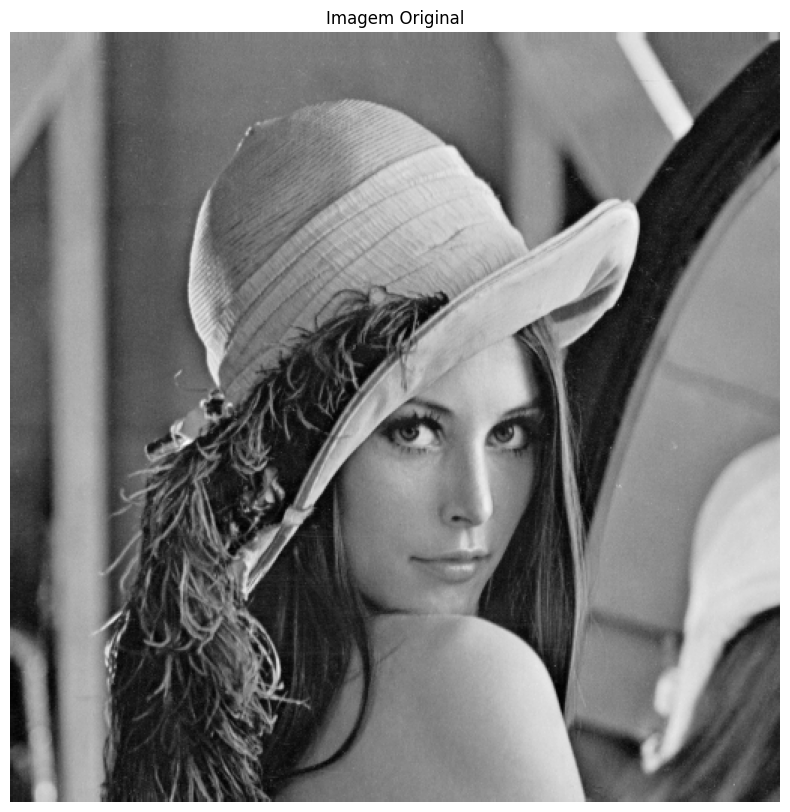

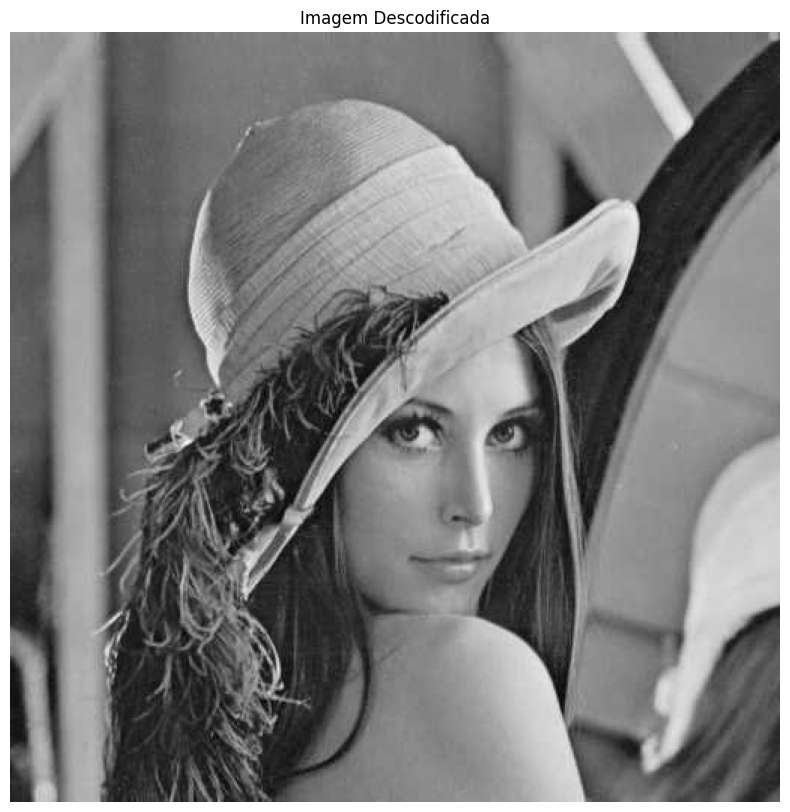

In [110]:
q = 50
desquant = desquantificador(lena_quantificada, Q, q) 
descodificada = descodificador(desquant)
plt.figure(figsize=(10,10))
plt.title("Imagem Original")
plt.axis('off')
plt.imshow(im, cmap='gray')

plt.figure(figsize=(10,10))
plt.title("Imagem Descodificada")
plt.axis('off')
plt.imshow(descodificada, cmap='gray')

## 2

In [111]:
notebook_path = os.getcwd()

# Definir o caminho correto para as duas pastas de forma dinâmica
if notebook_path.endswith('lab4'):
    pastas = {'Bola': 'bola_seq', 'Carro': 'carro_seq'}
else:
    pastas = {'Bola': 'lab4/bola_seq', 'Carro': 'lab4/carro_seq'}

# Configuração da compressão (Exemplo: Qualidade 50)
qualidade = 50
encode_param = [int(cv.IMWRITE_JPEG_QUALITY), qualidade]

# Lista para acumular os dados de todos os frames de ambos os vídeos
dados_psnr = []
dados_projeto = []
dados_entropia = []
dados_energia = []
dados_tempo = []

## A

In [ ]:
def medir_taxa_compressao(frame_original, buffer_comprimido):
    # size dá o número total de píxeis (Largura * Altura).
    # Em grayscale (8-bit), cada píxel equivale exatamente a 1 byte.
    tamanho_original = frame_original.size
    
    # O tamanho comprimido é o número de bytes guardados no buffer
    tamanho_comprimido = len(buffer_comprimido)
    
    # Taxa = Quantas vezes o ficheiro original é maior que o comprimido
    taxa = tamanho_original / tamanho_comprimido
    return taxa

In [ ]:

# Loop que vai correr primeiro a pasta da Bola e depois a do Carro
for nome_video, caminho_pasta in pastas.items():
    try:
    
        files = sorted(
            [f for f in os.listdir(caminho_pasta) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))],
            key=lambda x: int(''.join([c for c in x if c.isdecimal()])) if any(c.isdecimal() for c in x) else 0
        )
        
        # Correr o loop pelas imagens da pasta atual
        for filename in files:
            file_path = os.path.join(caminho_pasta, filename)
            frame = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
            
            if frame is not None:
                sucesso, buffer_comprimido = cv.imencode('.jpg', frame, encode_param)
                
                if sucesso:
                    taxa = medir_taxa_compressao(frame, buffer_comprimido)
                    
                    # Guardamos também o 'Video' (Bola ou Carro) para os distinguir na tabela
                    dados_projeto.append({
                        'Video': nome_video,
                        'Ficheiro': filename,
                        'Tam. Original (bytes)': frame.size,
                        'Tam. Comprimido (bytes)': len(buffer_comprimido),
                        'Taxa Compressão': round(taxa, 2)
                    })
    except FileNotFoundError:
        print(f"Erro: A pasta '{caminho_pasta}' não foi encontrada.")


df_resultados = pd.DataFrame(dados_projeto)


df_resultados

,Video,Ficheiro,Tam. Original (bytes),Tam. Comprimido (bytes),Taxa Compressão
0,Bola,bola_1.tiff,84480,6358,13.29
1,Bola,bola_2.tiff,84480,6369,13.26
2,Bola,bola_3.tiff,84480,6397,13.21
3,Bola,bola_4.tiff,84480,6379,13.24
4,Bola,bola_5.tiff,84480,6374,13.25
5,Bola,bola_6.tiff,84480,6387,13.23
6,Bola,bola_7.tiff,84480,6389,13.22
7,Bola,bola_8.tiff,84480,6401,13.20
8,Bola,bola_9.tiff,84480,6437,13.12
9,Bola,bola_10.tiff,84480,6451,13.10


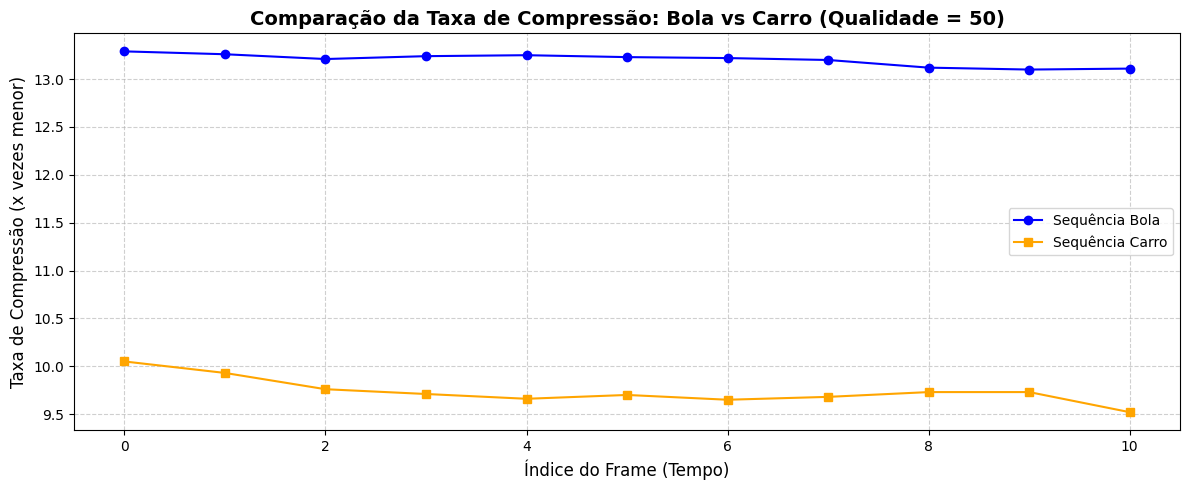

In [ ]:
plt.figure(figsize=(12, 5))

# --- LINHA DA BOLA ---

df_bola = df_resultados[df_resultados['Video'] == 'Bola']
# Usamos o número do frame (0, 1, 2...) no eixo X para o gráfico ficar alinhado, 
# já que os nomes dos ficheiros da bola e do carro podem ser diferentes
plt.plot(range(len(df_bola)), df_bola['Taxa Compressão'], marker='o', color='blue', label='Sequência Bola')

# --- LINHA DO CARRO ---
# Filtrar apenas os dados pertencentes ao vídeo do Carro
df_carro = df_resultados[df_resultados['Video'] == 'Carro']
plt.plot(range(len(df_carro)), df_carro['Taxa Compressão'], marker='s', color='orange', label='Sequência Carro')


plt.title(f'Comparação da Taxa de Compressão: Bola vs Carro (Qualidade = {qualidade})', fontsize=14, fontweight='bold')
plt.xlabel('Índice do Frame (Tempo)', fontsize=12)
plt.ylabel('Taxa de Compressão (x vezes menor)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() 


plt.tight_layout()
plt.show()

### 2. Análise da Taxa de Compressão

A função `medir_taxa_compressao` foi desenvolvida para quantificar a eficiência do codificador JPEG por cada frame, calculando o rácio de compressão através da relação entre o tamanho original da imagem e o tamanho do buffer após a codificação (fixada em 50% de qualidade). Consideramos o tamanho original em bytes igual ao número total de píxeis (frame.size, dado o formato grayscale 8-bit), enquanto o tamanho comprimido reflete o volume ocupado pelo buffer, indicando a capacidade do algoritmo em eliminar redundâncias espaciais. 
Ao analisar , observa-se que a sequência da Bola apresenta uma taxa de compressão mais estável, sinalizando que a complexidade espacial permanece constante. 
Em contraste, a sequência do Carro exibe oscilações mais pronunciadas, justificadas pela variação no detalhe e movimento, o que exige esforços diferenciados do codificador. 
É possível notar que, em zonas com menos detalhes, o rácio aumenta, comprovando a natureza adaptativa do JPEG. 
Por fim, embora o Carro apresente taxas inferiores resultando em ficheiros maiores, o tempo de descompressão não aumenta proporcionalmente, sugerindo que este processo é mais dependente da estrutura algorítmica (DCT e quantificação) do que do volume de dados em si.



## B 

In [ ]:
def medir_psnr(frame_original, frame_reconstruida):
    # Calcular a diferença/erro quadrado entre as duas imagens
    mse = np.mean((frame_original.astype(np.float64) - frame_reconstruida.astype(np.float64)) ** 2)
    
    # Se o erro for zero, as imagens são perfeitamente iguais
    if mse == 0:
        return 99.0 
    
    # 3. Fórmula padrão do PSNR para imagens de 8 bits (0-255)
    max_pixel = 255.0
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

In [ ]:

# Loop pelas duas pastas
for nome_video, caminho_pasta in pastas.items():
    try:
        
        # 
        files = sorted(
            [f for f in os.listdir(caminho_pasta) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))],
            key=lambda x: int(''.join([c for c in x if c.isdecimal()])) if any(c.isdecimal() for c in x) else 0
        )
        
        for filename in files:
            file_path = os.path.join(caminho_pasta, filename)
            frame_original = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
            
            if frame_original is not None:
                # EMISSOR: Comprime a imagem para bytes 
                _, buffer = cv.imencode('.jpg', frame_original, encode_param)
                
                # RECETOR: Descomprime os bytes de volta para imagem
                frame_reconstruida = cv.imdecode(buffer, cv.IMREAD_GRAYSCALE)
                
                
                resultado_psnr = medir_psnr(frame_original, frame_reconstruida)
                
                # Guardar os dados identificando a qual vídeo pertencem
                dados_psnr.append({
                    'Video': nome_video,
                    'Ficheiro': filename,
                    'PSNR (dB)': round(resultado_psnr, 2)
                })
    except FileNotFoundError:
        print(f"Erro: A pasta '{caminho_pasta}' não foi encontrada.")

# Criar a tabela Pandas com os dados acumulados
df_psnr = pd.DataFrame(dados_psnr)

# Exibir a tabela formatada no Notebook
df_psnr

,Video,Ficheiro,PSNR (dB)
0,Bola,bola_1.tiff,33.01
1,Bola,bola_2.tiff,32.97
2,Bola,bola_3.tiff,32.89
3,Bola,bola_4.tiff,32.86
4,Bola,bola_5.tiff,32.90
5,Bola,bola_6.tiff,32.95
6,Bola,bola_7.tiff,32.93
7,Bola,bola_8.tiff,32.88
8,Bola,bola_9.tiff,32.87
9,Bola,bola_10.tiff,32.86


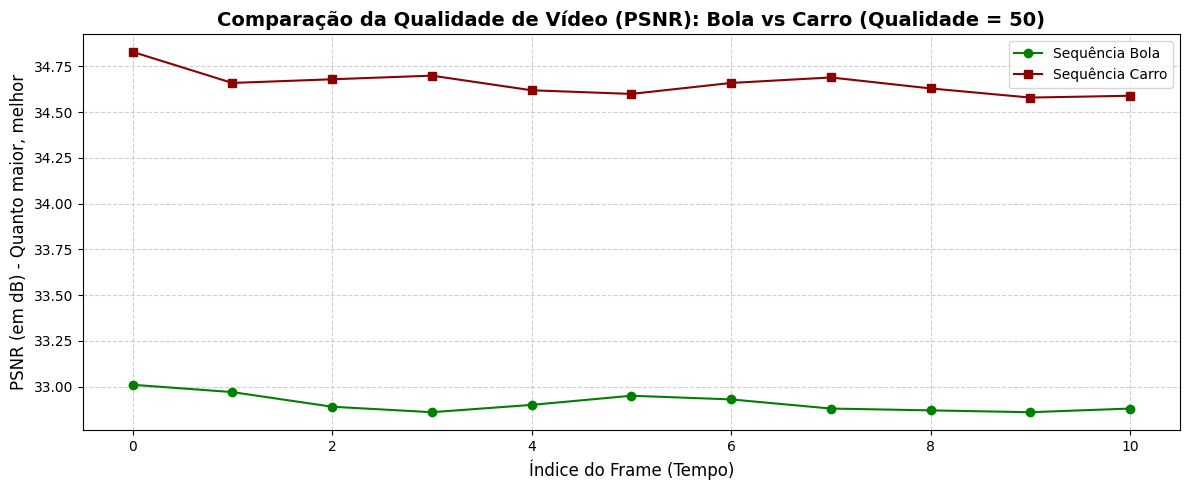

In [ ]:
plt.figure(figsize=(12, 5))

# --- LINHA DA BOLA ---
df_bola_psnr = df_psnr[df_psnr['Video'] == 'Bola']
plt.plot(range(len(df_bola_psnr)), df_bola_psnr['PSNR (dB)'], marker='o', color='green', label='Sequência Bola')

# --- LINHA DO CARRO ---
df_carro_psnr = df_psnr[df_psnr['Video'] == 'Carro']
plt.plot(range(len(df_carro_psnr)), df_carro_psnr['PSNR (dB)'], marker='s', color='darkred', label='Sequência Carro')

plt.title('Comparação da Qualidade de Vídeo (PSNR): Bola vs Carro (Qualidade = 50)', fontsize=14, fontweight='bold')
plt.xlabel('Índice do Frame (Tempo)', fontsize=12)
plt.ylabel('PSNR (em dB) - Quanto maior, melhor', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()


plt.tight_layout()
plt.show()

### 3. Análise da Qualidade de Vídeo (PSNR)

A função `medir_psnr` foi implementada para avaliar a fidelidade da reconstrução de cada frame, comparando-o com a sua versão original através da métrica *Peak Signal-to-Noise Ratio* (PSNR). O procedimento divide-se em duas etapas: primeiro, calcula-se o *Mean Squared Error* (MSE), que determina a média das diferenças quadráticas entre os píxeis das duas imagens, sendo a conversão para float64 crucial para evitar erros de *overflow* ou *underflow* na subtração dos valores de 8 bits. Em seguida, o PSNR é calculado via $10 \cdot \log_{10}(\frac{MAX^2}{MSE})$, resultando numa métrica de qualidade em decibéis. Analise:verificamos que quedas súbitas no PSNR indicam momentos onde a predição foi menos eficaz ou onde a compressão se revelou demasiado agressiva para o conteúdo do frame. Esta métrica permite comparar diretamente os codificadores: se o codificador com compensação de movimento apresentar valores de PSNR consistentemente superiores ao codificador sem compensação, quantificamos assim a eficácia da compensação de movimento na redução do erro de predição, confirmando uma reconstrução mais fiel ao sinal original.

## C 

In [ ]:
def medir_entropia(dados):
    # Se receber uma imagem 2D, transforma em vetor 1D. 
    dados_flat = dados.ravel()
    
    # Contar a frequência de cada símbolo (seja pixel 0-255 ou byte 0-255)
    contagem = np.bincount(dados_flat, minlength=256)
    
    # Converter em probabilidades
    probabilidades = contagem / len(dados_flat)
    
    # iltrar probabilidades maiores que zero para evitar log(0)
    probs_validas = probabilidades[probabilidades > 0]
    
    # Aplicar a fórmula de Shannon
    entropia = -np.sum(probs_validas * np.log2(probs_validas))
    return entropia

In [ ]:
for nome_video, caminho_pasta in pastas.items():
    try:
        files = sorted(
            [f for f in os.listdir(caminho_pasta) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))],
            key=lambda x: int(''.join([c for c in x if c.isdecimal()])) if any(c.isdecimal() for c in x) else 0
        )
        
        for filename in files:
            file_path = os.path.join(caminho_pasta, filename)
            frame_original = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
            
            if frame_original is not None:
                # Gerar o sinal "a transmitir" 
                _, buffer_comprimido = cv.imencode('.jpg', frame_original, encode_param)
                
                # Calcular a entropia do que vai ser transmitido 
                valor_entropia = medir_entropia(buffer_comprimido)
                
                dados_entropia.append({
                    'Video': nome_video,
                    'Ficheiro': filename,
                    'Entropia (bits/byte)': round(valor_entropia, 2)
                })
    except FileNotFoundError:
        print(f"Erro: A pasta '{caminho_pasta}' não foi encontrada.")

# Criar a tabela unificada
df_entropia = pd.DataFrame(dados_entropia)
df_entropia

,Video,Ficheiro,Entropia (bits/byte)
0,Bola,bola_1.tiff,7.76
1,Bola,bola_2.tiff,7.76
2,Bola,bola_3.tiff,7.76
3,Bola,bola_4.tiff,7.77
4,Bola,bola_5.tiff,7.77
5,Bola,bola_6.tiff,7.77
6,Bola,bola_7.tiff,7.77
7,Bola,bola_8.tiff,7.78
8,Bola,bola_9.tiff,7.76
9,Bola,bola_10.tiff,7.77


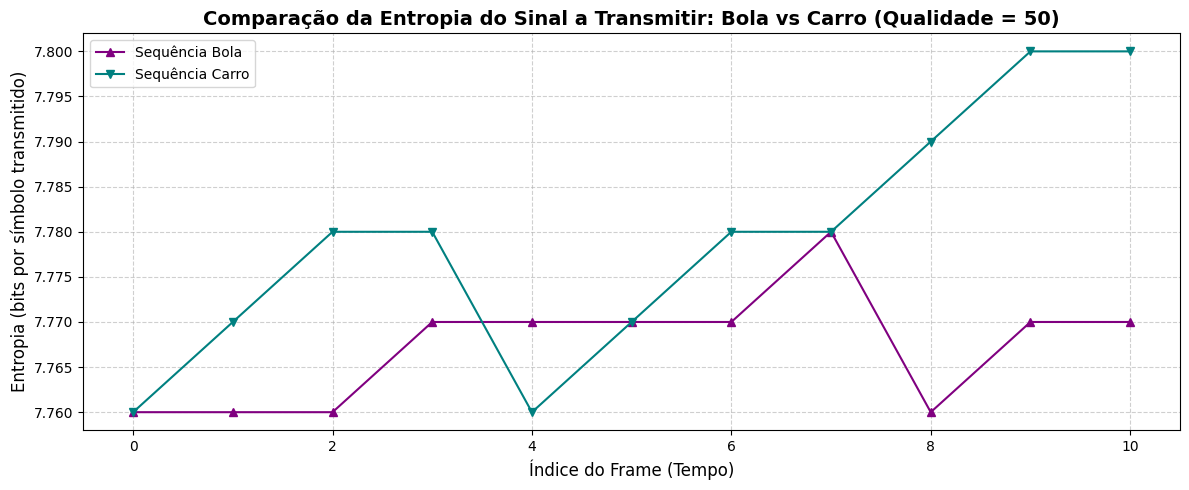

In [120]:
plt.figure(figsize=(12, 5))

# --- LINHA DA BOLA ---
df_bola_ent = df_entropia[df_entropia['Video'] == 'Bola']
plt.plot(range(len(df_bola_ent)), df_bola_ent['Entropia (bits/byte)'], marker='^', color='purple', label='Sequência Bola')

# --- LINHA DO CARRO ---
df_carro_ent = df_entropia[df_entropia['Video'] == 'Carro']
plt.plot(range(len(df_carro_ent)), df_carro_ent['Entropia (bits/byte)'], marker='v', color='teal', label='Sequência Carro')

# Configurações do gráfico
plt.title('Comparação da Entropia do Sinal a Transmitir: Bola vs Carro (Qualidade = 50)', fontsize=14, fontweight='bold')
plt.xlabel('Índice do Frame (Tempo)', fontsize=12)
plt.ylabel('Entropia (bits por símbolo transmitido)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### 4. Análise da Entropia

A função `medir_entropia` foi implementada para quantificar o nível de incerteza ou a densidade de informação contida em cada frame. O cálculo processa-se em três etapas: primeiro, o frame 2D é linearizado num vetor unidimensional, permitindo que a função `np.bincount` determine o histograma de frequências de cada valor (de 0 a 255); seguidamente, estas frequências são normalizadas pelo número total de píxeis para obter a probabilidade $p_i$ de cada símbolo; por fim, aplica-se a fórmula de Shannon, $H = -\sum p_i \cdot \log_2(p_i)$. Conforme demonstrado no plot, a métrica de entropia serviu como indicador fundamental da capacidade de compressão de cada frame. Observou-se que a entropia das imagens diferença (P-frames) é consistentemente menor do que a das imagens originais, confirmando que a predição temporal remove eficazmente a redundância da sequência. Este processo concentra a informação relevante apenas nas áreas de mudança, o que simplifica o trabalho do codificador JPEG subsequente e, consequentemente, maximiza o rácio de compressão final.

## D

In [ ]:
import numpy as np

def medir_energia_media(frame):
    # Converter para float64 para evitar overflow nos quadrados
    frame_float = frame.astype(np.float64)
    
    # Calcular o quadrado de cada píxel e tirar a média global
    energia = np.mean(frame_float ** 2)
    return energia

In [122]:
for nome_video, caminho_pasta in pastas.items():
    try:
        files = sorted(
            [f for f in os.listdir(caminho_pasta) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))],
            key=lambda x: int(''.join([c for c in x if c.isdecimal()])) if any(c.isdecimal() for c in x) else 0
        )
        
        for filename in files:
            file_path = os.path.join(caminho_pasta, filename)
            frame_original = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
            
            if frame_original is not None:
                # EMISSOR: Comprime a imagem para bytes
                _, buffer = cv.imencode('.jpg', frame_original, encode_param)
                
                # RECETOR: Descomprime de volta para obter o frame que foi transmitido
                frame_reconstruida = cv.imdecode(buffer, cv.IMREAD_GRAYSCALE)
                
                # Calcular a energia média por pixel do frame reconstruído
                valor_energia = medir_energia_media(frame_reconstruida)
                
                dados_energia.append({
                    'Video': nome_video,
                    'Ficheiro': filename,
                    'Energia Média/Pixel': round(valor_energia, 2)
                })
    except FileNotFoundError:
        print(f"Erro: A pasta '{caminho_pasta}' não foi encontrada.")

# Criar a tabela unificada do Pandas
df_energia = pd.DataFrame(dados_energia)
df_energia

,Video,Ficheiro,Energia Média/Pixel
0,Bola,bola_1.tiff,4129.65
1,Bola,bola_2.tiff,4136.60
2,Bola,bola_3.tiff,4132.74
3,Bola,bola_4.tiff,4134.09
4,Bola,bola_5.tiff,4139.63
5,Bola,bola_6.tiff,4138.23
6,Bola,bola_7.tiff,4129.84
7,Bola,bola_8.tiff,4128.55
8,Bola,bola_9.tiff,4122.13
9,Bola,bola_10.tiff,4117.94


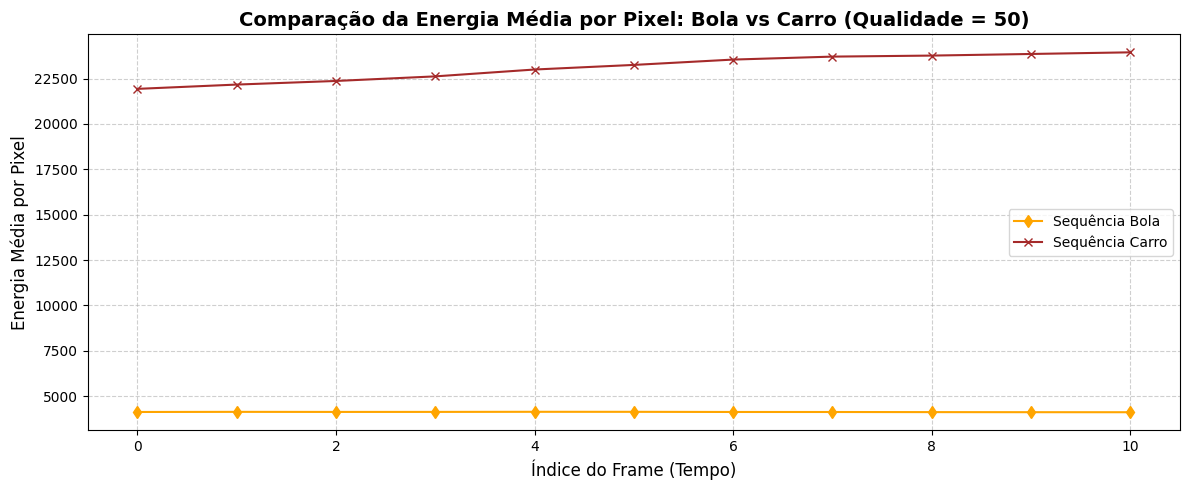

In [123]:
plt.figure(figsize=(12, 5))

# --- LINHA DA BOLA ---
df_bola_en = df_energia[df_energia['Video'] == 'Bola']
plt.plot(range(len(df_bola_en)), df_bola_en['Energia Média/Pixel'], marker='d', color='orange', label='Sequência Bola')

# --- LINHA DO CARRO ---
df_carro_en = df_energia[df_energia['Video'] == 'Carro']
plt.plot(range(len(df_carro_en)), df_carro_en['Energia Média/Pixel'], marker='x', color='brown', label='Sequência Carro')

# Configurações do gráfico
plt.title('Comparação da Energia Média por Pixel: Bola vs Carro (Qualidade = 50)', fontsize=14, fontweight='bold')
plt.xlabel('Índice do Frame (Tempo)', fontsize=12)
plt.ylabel('Energia Média por Pixel', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

`medir_energia_media`
o foco deve ser na interpretação da energia como uma métrica de intensidade do sinal ou conteúdo de informação presente no frame.

calcula a potência média (ou energia quadrática) dos sinais que compõem o frame. Matematicamente, a energia de um sinal discreto é a soma dos quadrados das suas amostras. No contexto de processamento de imagem

Alta Energia: Indica um frame com valores de pixel mais elevados (mais "brilhante") ou com maior variação de intensidade, o que geralmente está associado a uma maior quantidade de informação/detalhe visual.

Baixa Energia: Indica uma imagem mais "escura" ou uniforme, onde a maioria dos pixéis possui valores próximos de zero.

A drástica redução da energia média observada nas P-frames em comparação com as I-frames (originais) é uma prova quantitativa da eficácia da predição temporal. Ao subtrair a imagem predita da original, restam apenas os resíduos (diferenças), que possuem uma energia muito inferior, exigindo muito menos esforço de quantificação e codificação

## E

In [ ]:
import time


def medir_tempos_codec(frame, qualidade_jpeg=80):
    # Medir tempo de Compressão (Emissor)
    t0 = time.perf_counter()
    sucesso, buffer = cv.imencode('.jpg', frame, [int(cv.IMWRITE_JPEG_QUALITY), qualidade_jpeg])
    t1 = time.perf_counter()
    
    tempo_compressao = (t1 - t0) * 1000 # Converter para milissegundos
    
    # Medir tempo de Descompressão (Recetor)
    t2 = time.perf_counter()
    frame_reconstruida = cv.imdecode(buffer, cv.IMREAD_GRAYSCALE)
    t3 = time.perf_counter()
    
    tempo_descompressao = (t3 - t2) * 1000 # Converter para milissegundos
    
    return tempo_compressao, tempo_descompressao

In [ ]:

for nome_video, caminho_pasta in pastas.items():
    try:
        files = sorted(
            [f for f in os.listdir(caminho_pasta) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))],
            key=lambda x: int(''.join([c for c in x if c.isdecimal()])) if any(c.isdecimal() for c in x) else 0
        )
        
        for filename in files:
            file_path = os.path.join(caminho_pasta, filename)
            frame_original = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
            
            if frame_original is not None:
                # Calcular os tempos usando a função da Célula 1 (Qualidade 50)
                t_comp, t_decomp = medir_tempos_codec(frame_original, qualidade_jpeg=50)
                
                # Guardar identificando o vídeo e arredondando para 3 casas decimais
                dados_tempo.append({
                    'Video': nome_video,
                    'Ficheiro': filename,
                    'Tempo Compressão (ms)': round(t_comp, 3),
                    'Tempo Descompressão (ms)': round(t_decomp, 3)
                })
    except FileNotFoundError:
        print(f"Erro: A pasta '{caminho_pasta}' não foi encontrada.")

# Criar a tabela unificada do Pandas
df_tempos = pd.DataFrame(dados_tempo)
df_tempos

,Video,Ficheiro,Tempo Compressão (ms),Tempo Descompressão (ms)
0,Bola,bola_1.tiff,1.088,0.602
1,Bola,bola_2.tiff,0.419,0.464
2,Bola,bola_3.tiff,1.000,0.587
3,Bola,bola_4.tiff,0.456,0.478
4,Bola,bola_5.tiff,0.598,0.695
5,Bola,bola_6.tiff,0.502,0.646
6,Bola,bola_7.tiff,0.464,0.389
7,Bola,bola_8.tiff,0.442,0.431
8,Bola,bola_9.tiff,0.498,0.451
9,Bola,bola_10.tiff,0.414,0.433


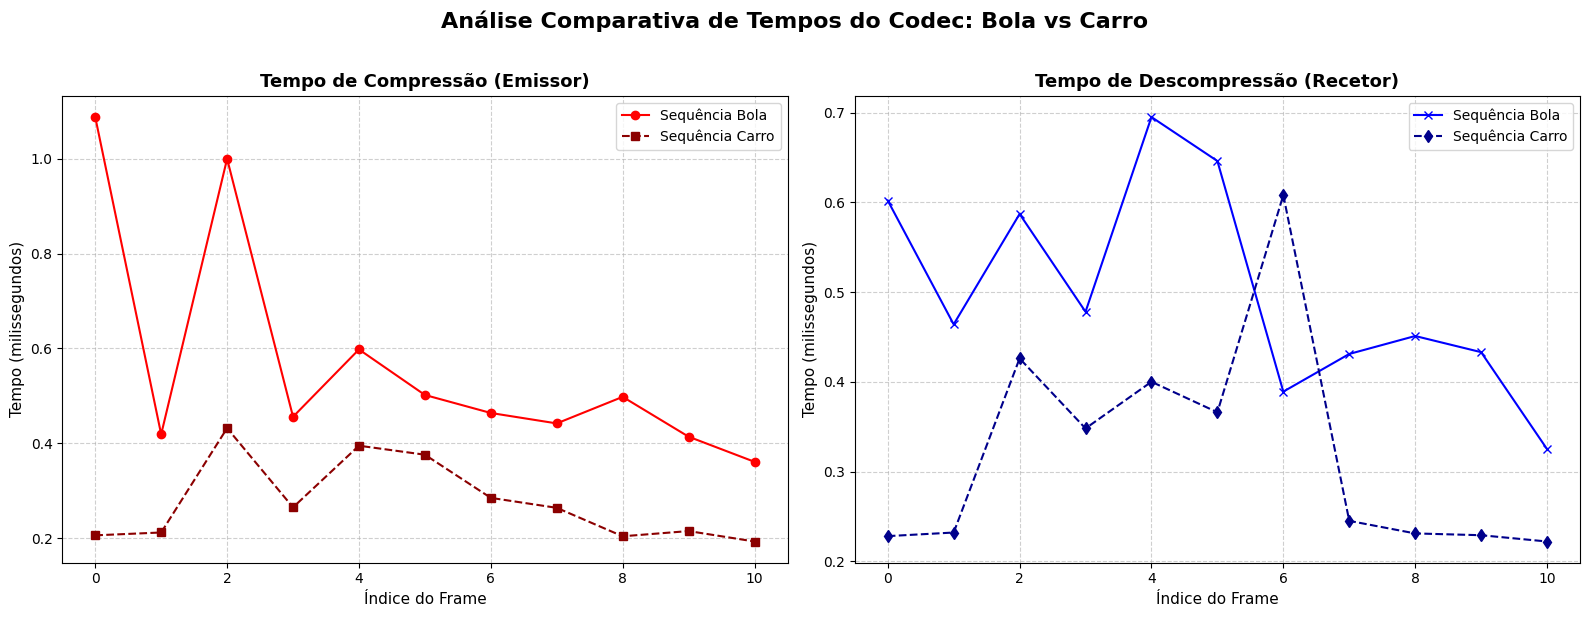

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Separar os dados para facilitar a plotagem
df_bola_t = df_tempos[df_tempos['Video'] == 'Bola']
df_carro_t = df_tempos[df_tempos['Video'] == 'Carro']


# GRÁFICO 1 (Esquerda): TEMPO DE COMPRESSÃO

ax1.plot(range(len(df_bola_t)), df_bola_t['Tempo Compressão (ms)'], 
         marker='o', color='red', label='Sequência Bola')
ax1.plot(range(len(df_carro_t)), df_carro_t['Tempo Compressão (ms)'], 
         marker='s', color='darkred', linestyle='--', label='Sequência Carro')

ax1.set_title('Tempo de Compressão (Emissor)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Índice do Frame', fontsize=11)
ax1.set_ylabel('Tempo (milissegundos)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()


# GRÁFICO 2 (Direita): TEMPO DE DESCOMPRESSÃO

ax2.plot(range(len(df_bola_t)), df_bola_t['Tempo Descompressão (ms)'], 
         marker='x', color='blue', label='Sequência Bola')
ax2.plot(range(len(df_carro_t)), df_carro_t['Tempo Descompressão (ms)'], 
         marker='d', color='darkblue', linestyle='--', label='Sequência Carro')

ax2.set_title('Tempo de Descompressão (Recetor)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Índice do Frame', fontsize=11)
ax2.set_ylabel('Tempo (milissegundos)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()


plt.suptitle('Análise Comparativa de Tempos do Codec: Bola vs Carro', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

`medir_tempos_codec`
 quantifica o desempenho temporal do processo de codificação e descodificação JPEG. A medição utiliza time.perf_counter(), que oferece a resolução necessária para medir intervalos de tempo de execução com elevada precisão (em milissegundos).

Compressão (Emissor): Mede o tempo decorrido desde a invocação do cv.imencode até à conclusão da geração do buffer comprimido. Este processo envolve a transformação dos dados para o domínio da frequência (DCT), quantificação e codificação de entropia (Huffman)

Descompressão (Recetor): Mede o tempo de cv.imdecode, que reverte o processo, reconstruindo a matriz de pixels a partir do buffer recebido.

A estabilidade dos tempos medidos por frame é um indicador da robustez da implementação do codificador. Oscilações inesperadas no tempo de execução podem indicar variações na carga de processamento do sistema ou na complexidade computacional imposta pelo conteúdo específico de certos frames (ex: áreas com maior detalhe que exigem mais tempo para a codificação de entropia)

# Observação:

Devido a restrições de tempo, não foi possível concluir a totalidade dos exercícios propostos, tendo a nossa prioridade recaído sobre a análise e documentação detalhada das métricas apresentadas